In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons

In [2]:
x,y=make_moons(n_samples=1000,noise=0.2)

In [3]:
df={"x1":x[:,0],"x2":x[:,1],"y":y}

In [4]:
data=pd.DataFrame(df)
data

,x1,x2,y
0,-0.570614,0.751345,0
1,-0.009508,0.182361,1
2,0.655810,-0.403569,1
3,2.022389,-0.091053,1
4,-0.517982,0.794333,0
...,...,...,...
995,-0.079931,0.690904,0
996,1.807829,0.360503,1
997,0.089916,0.383512,1
998,0.319763,0.894207,0


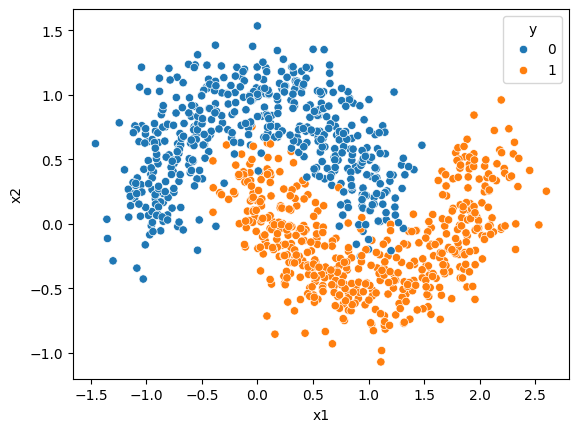

In [5]:
sns.scatterplot(x="x1",y="x2",hue="y",data=data,)
plt.show()

In [6]:
x_a=data.iloc[:,:-1]
y_a=data["y"]

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
x_train,x_test,y_train,y_test=train_test_split(x_a,y_a,test_size=0.2,random_state=42)

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [10]:
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)
dt.score(x_train,y_train)*100,dt.score(x_test,y_test)*100

(100.0, 96.5)

In [11]:
svc=SVC()
svc.fit(x_train,y_train)
svc.score(x_train,y_train)*100,svc.score(x_test,y_test)*100

(97.125, 98.0)

In [12]:
gnb=GaussianNB()
gnb.fit(x_train,y_train)
gnb.score(x_train,y_train)*100,gnb.score(x_test,y_test)*100

(87.125, 87.0)

In [13]:
from sklearn.ensemble import VotingClassifier

In [14]:
li=[("dt1",DecisionTreeClassifier()),("svc1",SVC()),("gnb1",GaussianNB())]

In [15]:
vc=VotingClassifier(li,weights=[10,4,7])
vc.fit(x_train,y_train)


VotingClassifier(estimators=[('dt1', DecisionTreeClassifier()), ('svc1', SVC()),
                             ('gnb1', GaussianNB())],
                 weights=[10, 4, 7])

In [16]:
vc.score(x_train,y_train)*100,vc.score(x_test,y_test)*100

(98.0, 97.5)

In [17]:
prd={"dt":dt.predict(x_test),"svc":svc.predict(x_test),"gnb":gnb.predict(x_test),"vc":vc.predict(x_test)}

In [18]:
pd.DataFrame(prd)

,dt,svc,gnb,vc
0,0,0,0,0
1,1,1,1,1
2,0,0,0,0
3,0,0,0,0
4,0,0,1,0
...,...,...,...,...
195,1,1,1,1
196,0,0,0,0
197,0,0,1,0
198,0,0,0,0
